<figure>
  <IMG src="figures/logo-esi-sba.png" WIDTH=300 height="100" ALIGN="right">
</figure>

# Practical Trainining Series on Software Engineering For Data Science  
*By Dr. Belkacem KHALDI (b.khaldi@esi-sba.dz)*

## Introduction

This notebook guides you through the mastery of **Advanced Data Visualization** techniques, focusing on statistical rigor (Seaborn), and dynamic plot generation (Plotly). These skills are vital for interactive data exploration and powerful storytelling, as emphasized in Lecture SEDS-Lecture 07-2025.

**Required Libraries:** We will utilize core Python libraries: `pandas`, `numpy`, `plotly` (including `plotly.express` and `plotly.graph_objects`), and `seaborn`.

### Setup: Importing Necessary Libraries

In [1]:
# Core Data Handling and Visualization Libraries
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt # For rendering Seaborn plots


## Module 1: Foundational Data Preparation and EDA Tutorials

Advanced EDA emphasizes visualization techniques over basic procedures. This module covers preparing data quality and transformation.

### **Tutorial 1.1: Automated and Missing Data Analysis**

**Objective:** Understand data structure and missingness patterns using visualization and automated tools.

#### **Step 1: Missing Data Visualization using `missingno`**
Missing data (values that are blank, NaN, or zero when they shouldn't be) can be problematic for visualizations and must be dealt with. The `missingno` library visualizes patterns of missing data.

**Implementation Steps:**
1. Load a dataset that contains missing values.
2. Use the `.matrix(df)` function to generate a visualization of missing data patterns.


In the following example we will use the `itunes_data` in the data folder. Note you should first install the library using pip or conda.


In [2]:
!pip install missingno

Then the following code will create a data completeness matrix using the missingno library. The visualization shows:
- **Black bars**: Present data in each column.
- **White gaps**: Missing values.
- **Patterns**: How missing data is distributed across your dataset.

With this type of visual representation, you can quickly identify which columns have the most missing values and whether there are any systematic patterns in data completeness. The right-side bar chart shows overall data density across all rows.

This helps assess data quality before analysis and decide if missing value handling is needed.

<Axes: >

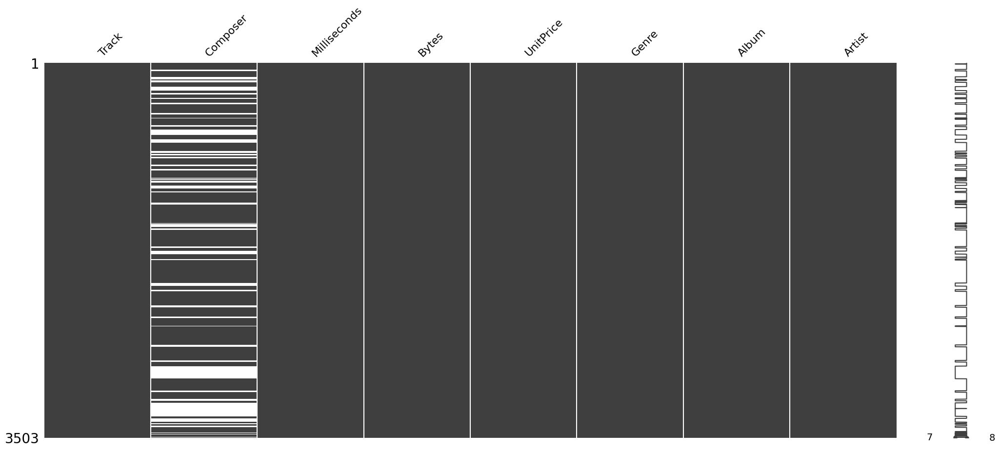

In [3]:
import pandas as pd
import missingno as msno


df = pd.read_csv('data/itunes_data.csv')
msno.matrix(df)

To analyze the missing data patterns in the itunes_data DataFrame from the msno.matrix(df) visualization, you can interpret the graph as follows to answer your questions:

**Analyzing Missing Data Patterns with msno.matrix:**

**Column Patterns:**
- More white gaps = more missing values
- Solid black columns = complete data
- Visually rank columns by white space proportion

**Row Patterns:**
- Horizontal white gaps = rows with multiple missing values
- White bands = clustered missingness across rows
- Right-side bar chart shows data completeness per row

**Systematic Patterns:**
- Scattered white gaps = random missingness
- White blocks/aligned gaps = systematic patterns
- Parallel gaps in columns suggest related missingness

**Note:** For precise missing data correlations, use `msno.dendrogram()` instead.

nterpreting msno.dendrogram(df)
What is a Dendrogram?

A dendrogram is a tree-like diagram that shows hierarchical relationships between variables based on their missing data patterns.

How to Read the Dendrogram:

**Key Interpretation:**

1. Branch Length = Correlation Strength
    - Shorter branches = stronger correlation in missingness patterns
    - Longer branches = weaker correlation

2. Cluster Groups
    - Columns that cluster together have similar missing data patterns
    - If Column X and Column Y are missing together frequently, they'll be close
3. Root Level
    - The top level shows overall similarity structure
    - Early splits indicate major differences in missingness behavior

<Axes: >

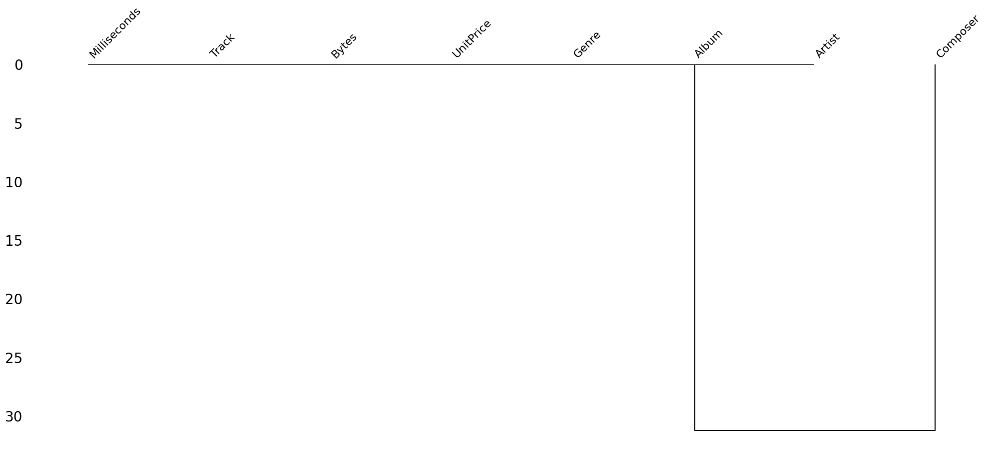

In [4]:
msno.dendrogram(df)

#### **Challenge 1: Missing Data Patterns Challenge**
Analyze the Titanic dataset focusing ONLY on missing value patterns:
`sns.load_dataset('titanic')`

##### **Your Tasks:**
1. **Column Analysis**: Identify which columns have the most/least missing data
2. **Pattern Detection**: Find systematic vs random missingness patterns  
3. **Cluster Relationships**: Use `msno.dendrogram()` to find columns with correlated missingness

Focus only on missing data patterns - no additional analysis!

In [5]:
# Your Code
# Load the Titanic dataset
titanic_df = sns.load_dataset('titanic')

print("Titanic Dataset Shape:", titanic_df.shape)
print("\nMissing Values by Column:")
print(titanic_df.isnull().sum())

Titanic Dataset Shape: (891, 15)

Missing Values by Column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


<Figure size 1200x600 with 0 Axes>

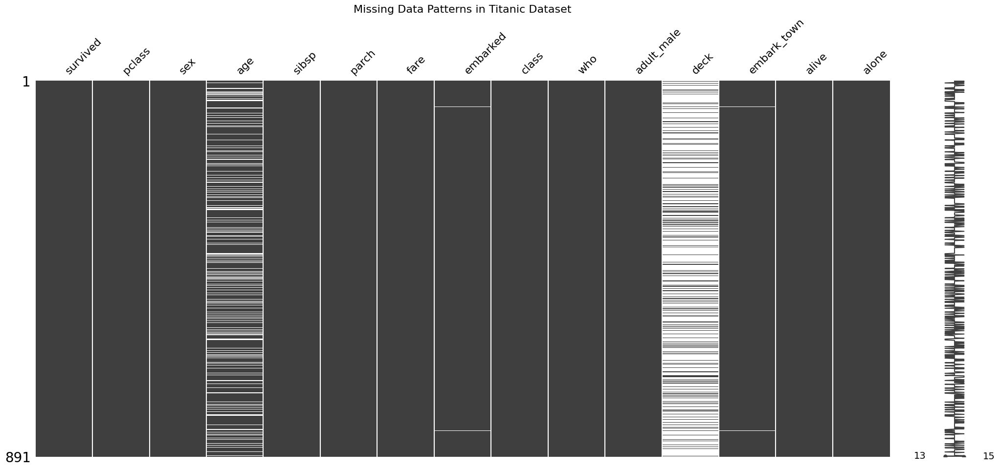

In [6]:
# Create the missing data matrix
plt.figure(figsize=(12, 6))
msno.matrix(titanic_df)
plt.title('Missing Data Patterns in Titanic Dataset', fontsize=16)
plt.show()

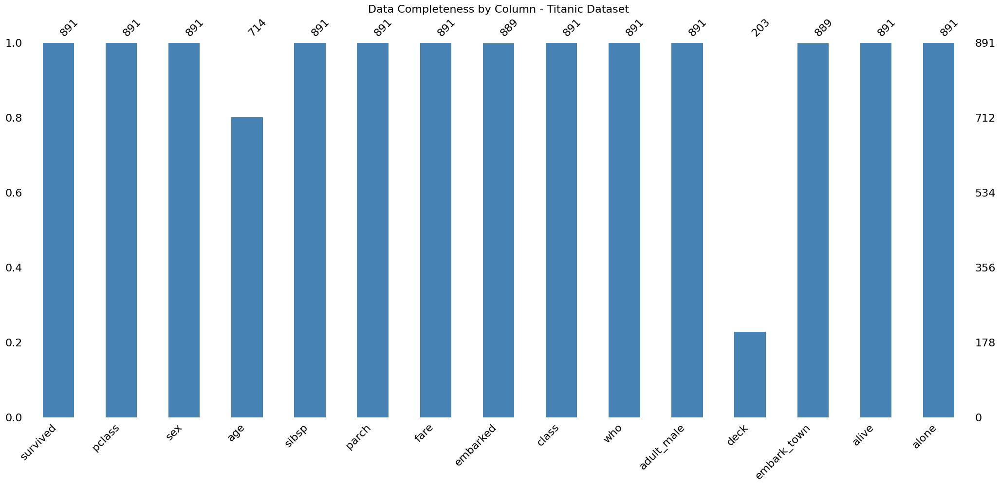

In [7]:
# Bar chart for precise missing value counts
plt.figure(figsize=(12, 6))
msno.bar(titanic_df, color='steelblue')
plt.title('Data Completeness by Column - Titanic Dataset', fontsize=16)
plt.show()

<Figure size 1200x800 with 0 Axes>

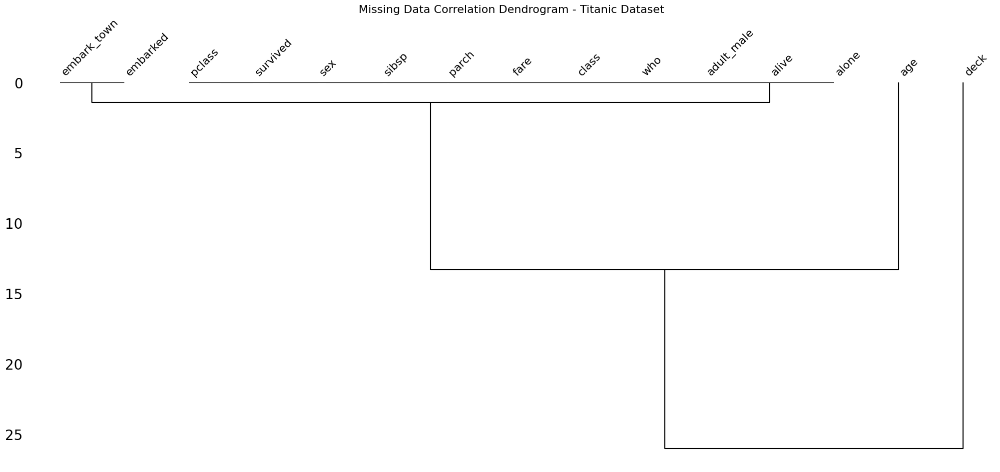

In [8]:
# Dendrogram to find columns with correlated missingness patterns
plt.figure(figsize=(12, 8))
msno.dendrogram(titanic_df)
plt.title('Missing Data Correlation Dendrogram - Titanic Dataset', fontsize=16)
plt.show()


#### **Step 2: Conceptual Automated EDA using ydata-profiling**
Automated EDA tools, such as `ydata-profiling`, streamline preliminary analysis and produce ca **comprehensive automated data analysis report**  efficiently.

##### What This Creates:

**A Complete Data Quality Dashboard** that includes:

- **Dataset Overview**: Number of variables, observations, missing cells, and memory usage
- **Variable Analysis**: Detailed statistics for each column (type, unique values, missing values, distribution)
- **Interactions**: Correlation analysis between variables  
- **Missing Values**: Pattern analysis and visualization
- **Sample Data**: First and last rows of the dataset


The report provides both high-level overview and detailed variable-level analysis, making it an essential first step in any data science project.
Note you should first install the library using pip or conda.

In [9]:
!pip install ydata-profiling

In [10]:
from ydata_profiling import ProfileReport

report = ProfileReport(df, title="Report") # Report is generated with minimal cod
report

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:00<00:00, 54.51it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

#### **Challenge 2: Automated EDA Challenge: Titanic Dataset**

Generate a comprehensive automated EDA report for the Titanic dataset using `ydata_profiling`.

## Your Mission:

1. **Create a full automated EDA report**
2. **Identify 3 key data quality issues**
3. **Find 2 interesting correlations** between variables


In [39]:
report = ProfileReport(titanic_df, title="Report") # Report is generated with minimal cod
report

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 15/15 [00:00<00:00, 353.37it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [11]:
#Your Solution

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

olympic_df = pd.read_csv('data/athlete_events.csv')


In [12]:
# Data preparation for violin plot
# Filter data for medal winners and relevant columns
medal_data = olympic_df[
    (olympic_df['Medal'].isin(['Gold', 'Silver', 'Bronze'])) & 
    (olympic_df['Height'].notna()) & 
    (olympic_df['Weight'].notna())
].copy()

# Create the violin plot using Plotly for interactivity
fig = px.violin(
    medal_data, 
    x='Sex', 
    y='Height', 
    color='Medal',
    facet_col='Medal',
    title='Distribution of Athlete Height by Gender and Medal Type - Olympic History',
    labels={'Height': 'Height (cm)', 'Sex': 'Gender'},
    category_orders={'Medal': ['Gold', 'Silver', 'Bronze']},
    color_discrete_map={'Gold': 'gold', 'Silver': 'silver', 'Bronze': '#cd7f32'}
)

fig.update_layout(
    height=600,
    showlegend=True
)

fig.show()

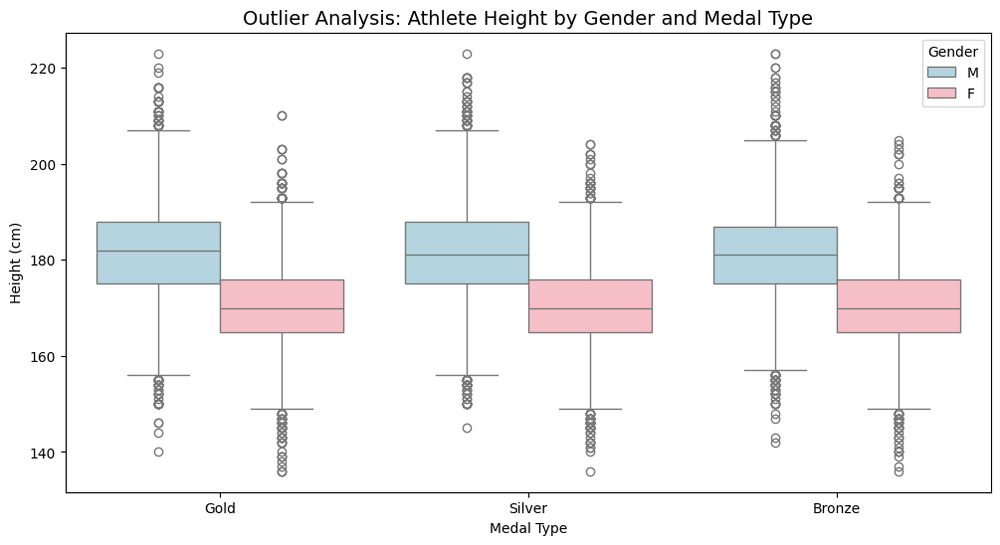

In [13]:
# Method 1: Box Plots for Outlier Detection
plt.figure(figsize=(12, 6))

# Create box plots for height by gender and medal type
sns.boxplot(
    data=medal_data,
    x='Medal', 
    y='Height', 
    hue='Sex',
    palette=['lightblue', 'lightpink'],
    order=['Gold', 'Silver', 'Bronze']
)

plt.title('Outlier Analysis: Athlete Height by Gender and Medal Type', fontsize=14)
plt.ylabel('Height (cm)')
plt.xlabel('Medal Type')
plt.legend(title='Gender')
plt.show()

## Module 2: Distribution and Relationship Visualization Tutorials

This module focuses on statistical characteristics and relationships using scatter plots, histograms, and heatmaps.

### **Tutorial 2.1: Advanced Distribution Comparisons**

**Objective:** Generate Box Plots to check for outliers and Violin Plots to visualize density and distribution spread across categories.

#### **Step 1: Visualize Outliers with a Box Plot (Plotly Express)**
Box plots summarize distribution statistics and help check for outliers.



In [14]:
# Load built-in Plotly dataset for initial examples
df_g = px.data.gapminder()

# Box Plot showing Life Expectancy distribution by Continent
# Create interactive boxplot
fig = px.box(df_g, x='continent',  y='lifeExp',   color='continent',
    title='Interactive Life Expectancy Distribution by Continent (1952-2007)',
    labels={'lifeExp': 'Life Expectancy (years)', 'continent': 'Continent'},
    hover_data=['country'],  # Show country name on hover
    template='plotly_dark'
)
fig.show()


**Adding an interactive sliders for years:**

In [15]:
# Add year slider for interactivity
fig.update_layout(
    sliders=[{
        'active': 0,
        'currentvalue': {'prefix': 'Year: '},
        'steps': [
            {
                'args': [
                    {'x': [df_g[df_g['year'] == year]['continent']],
                     'y': [df_g[df_g['year'] == year]['lifeExp']]},
                    {'title': f'Life Expectancy by Continent - {year}'}
                ],
                'label': str(year),
                'method': 'update'
            }
            for year in sorted(df_g['year'].unique())
        ]
    }]
)

# Customize hover information
fig.update_traces(
    hovertemplate='<b>Continent:</b> %{x}<br>' +
                  '<b>Life Expectancy:</b> %{y:.1f} years<br>' +
                  '<extra></extra>'
)

fig.show()

#### **Step 2: Visualize Density with a Violin Plot**
Violin Plots show both distribution density (KDE) and box plot summary, useful for comparing distributions across categories.

In the following example, we added a dropdown input text to allow user interact with the plot in real-time


In [16]:
# Create initial violin plot (default to 2007)
initial_year = 2007
df_filtered = df_g[df_g['year'] == initial_year]

fig = px.violin(
    df_filtered,
    x='continent',
    y='lifeExp',
    color='continent',
    title=f'Life Expectancy Distribution by Continent - {initial_year}',
    labels={'lifeExp': 'Life Expectancy (years)', 'continent': 'Continent'},
    hover_data=['country'],
    template='plotly_dark'
)

# Create dropdown menu for year selection
dropdown_buttons = []
years = sorted(df_g['year'].unique())

for year in years:
    df_year = df_g[df_g['year'] == year]
    dropdown_buttons.append({
        'args': [
            {
                'y': [df_year[df_year['continent'] == cont]['lifeExp'] for cont in df_g['continent'].unique()],
                'x': [df_year['continent']]
            },
            {
                'title': f'Life Expectancy Distribution by Continent - {year}'
            }
        ],
        'label': str(year),
        'method': 'update'
    })

# Add dropdown menu to layout
fig.update_layout(
    updatemenus=[{
        'buttons': dropdown_buttons,
        'direction': 'down',
        'showactive': True,
        'x': 0.5,
        'y': 1.1,
        'xanchor': 'left',
        'yanchor': 'top',
        'bgcolor': 'lightblue',
        'bordercolor': 'black',
        'font': {'size': 12}
    }]
)

# Customize hover information
fig.update_traces(
    hovertemplate='<b>Continent:</b> %{x}<br>' +
                  '<b>Life Expectancy:</b> %{y:.1f} years<br>' +
                  '<extra></extra>'
)

fig.show()


### **Tutorial 2.2: Relationship Visualization using Scatter plots and Heatmaps**

**Objective:** Use Scatter Plots to show global patterns between two features and Heatmaps to visualize pairwise correlation.

#### **Step 1: Create an Interactive Scatter Plot with Animation**
Scatter plots are a great tool to learn more about two numerical attributes.

The following code creates an **interactive animated scatter plot** showing global development trends over time using the famous Gapminder dataset.

##### **What You'll See:**

- **X-axis**: GDP per capita (logarithmic scale)
- **Y-axis**: Life expectancy  
- **Bubble size**: Population
- **Colors**: Continents
- **Animation**: Year-by-year progression (1952-2007)


In [17]:
import plotly.express as px

df_animated = px.data.gapminder()

fig = px.scatter(df_animated,
                     x="gdpPercap", y="lifeExp", size="pop", color="continent",
                     log_x=True, size_max=60,
                     animation_frame="year", animation_group="country",
                     template="plotly_dark", title="Gapminder Animation - Theme: 'plotly_dark'")


fig.show()

#### **Step 2: Generate an Interactive Heatmap with Hover**
Heatmaps are matrices color-coded to indicate the strength of relationships (correlation).
The following code creates an **interactive heatmap** visualizing how average life expectancy evolved across continents over time.

##### **What the Visualization Shows:**

- **Y-axis**: Years (1952-2007)
- **X-axis**: Continents  
- **Color intensity**: Average life expectancy values
- **Interactive hover**: Detailed information for each cell


In [18]:
# Prepare data for heatmap: average life expectancy by year and continent
df_heatmap = df_g.groupby(['year', 'continent'])['lifeExp'].mean().unstack()

# Create interactive heatmap
fig = px.imshow(
    df_heatmap,
    x=df_heatmap.columns,
    y=df_heatmap.index,
    color_continuous_scale='Viridis',
    title='Average Life Expectancy by Continent and Year',
    labels={'x': 'Continent', 'y': 'Year', 'color': 'Avg. Life Expectancy'},
    aspect="auto", # Adjust aspect ratio
    template='plotly_dark'
)

# Customize hover info
fig.update_traces(
    hovertemplate="<b>Year:</b> %{y}<br>" +
                  "<b>Continent:</b> %{x}<br>" +
                  "<b>Avg. Life Expectancy:</b> %{z:.1f} years<extra></extra>"
)

# Update layout for better readability
fig.update_xaxes(side="top")

fig.show()


## Module 3: Interactive Visualization and Hierarchical Plot Tutorials (Plotly)

This module focuses on interactivity features, custom controls with Histograms, and visualizing hierarchical data structures using Plotly.

### **Tutorial 3.1: Custom Interactive Controls (Slider)**

**Objective:** Implement a custom slider control to dynamically modify a visualization parameter.

#### **Step 1: Create a Base Plotly Histogram and Add an Animation Slider**
This demonstrates adding a slider to the figure's layout to enable user-driven changes, such as modifying the number of bins (`nbins`).

The code below creates a **dynamic histogram** that shows how life expectancy distributions evolved across continents from 1952 to 2007.

##### **Key Features:**

- **Time Animation**: Watch distributions shift year by year
- **Continental Breakdown**: Colors show each continent's contribution
- **Bin Control**: Adjust histogram granularity (5-30 bins)
- **Dark Theme**: Modern, visually appealing interface




In [19]:
# Interactive histogram with year animation and bin control
fig = px.histogram(
    df_g,
    x='lifeExp',
    nbins=20,
    animation_frame='year',
    title='Life Expectancy Distribution Evolution (1952-2007)',
    labels={'lifeExp': 'Life Expectancy (years)'},
    color="continent",
    opacity=0.7,
    template='plotly_dark',
)

# Add bin control slider
fig.update_layout(
    sliders=[{
        'active': 0,
        'currentvalue': {'prefix': 'Bins: '},
        'steps': [
            {'args': ['nbins', bins], 'label': str(bins), 'method': 'restyle'}
            for bins in [5, 10, 15, 20, 25, 30]
        ]
    }],
    xaxis_title='Life Expectancy (years)',
    yaxis_title='Number of Countries'
)

fig.show()

### **Tutorial 3.2: Visualizing Hierarchical Data: Sunburst Charts**

**Objective:** Generate a Sunburst Chart, which displays hierarchical data, using Plotly Express.

#### **Step 1: Define Hierarchy and Values**
Use the `path` argument to define the hierarchy (e.g., Continent then Country) and `values` to size the segments (e.g., Population).

The following code creates an **interactive sunburst chart** visualizing the world population distribution through a hierarchical layout.

##### **Chart Structure:**

- **Inner rings**: Continents
- **Outer rings**: Individual countries  
- **Segment size**: Population (larger = more people)
- **Color intensity**: Life expectancy (darker = longer lives)

##### **Interactive Features:**

- Click segments to drill down/up the hierarchy
- Hover for detailed country statistics
- Compare population sizes and health metrics simultaneously
- Visualize continental and national distributions




In [20]:

# Using gapminder data (which contains hierarchy: continent -> country)
df_sunburst = px.data.gapminder().query("year == 2007")

fig_sunburst = px.sunburst(df_sunburst, path=['continent', 'country'],
                            values='pop', # Size of segments is based on population
                            color='lifeExp', # Color based on life expectancy
                            color_continuous_scale='Viridis',
                            template='plotly_dark',
                            title='Population Distribution by Continent and Country (Sunburst)')

fig_sunburst.show()

### Tutorial 3.3: Visualizing Hierarchical Data: Treemap Plots

**Objective:** Generate a Treemap Plot, another method for visualizing hierarchical structure and relative magnitudes, using Plotly Express.

#### **Step 1: Define Hierarchy and Values**
Similar to the Sunburst chart, use the `path` argument to set the hierarchy (Continent and Country).

This code creates an **interactive treemap** visualizing economic output distribution across the world in a space-filling hierarchy.

##### **Visual Encoding:**

- **Rectangle size**: GDP per capita (larger = wealthier)
- **Color intensity**: Population size (darker = more populous)
- **Hierarchy**: Continents → Countries nested structure
- **Layout**: Efficient space utilization

#### **Interactive Exploration:**

- Click to focus on specific continents/countries
- Hover for exact economic and demographic data
- Compare relative wealth and population simultaneously
- Identify economic giants and regional patterns



In [21]:
df_treemap = px.data.gapminder().query("year == 2007")

fig_treemap = px.treemap(df_treemap, path=['continent', 'country'],
                           values='gdpPercap', # Size of rectangles based on GDP per capita
                           color='pop',
                           color_continuous_scale='Viridis',
                           template='plotly_dark',
                           title='GDP per Capita by Continent and Country (Treemap)')

fig_treemap.show()

## Module 4: Faceting Techniques and Geospacial Visualization Tutorials

This module focuses on techniques for comparison (faceting) and geographical visualization (choropleth maps).

### Tutorial 4.1: Comparison using Faceting Techniques (Plotly Express)

**Objective:** Use faceting to split a single chart into multiple sub-charts based on a categorical variable, enhancing comparison across different strata.

#### **Step 1: Create a Single Chart and Apply Faceting**
Faceting is applied using the `facet_col` or `facet_row` argument in Plotly Express.

The code below creates a **multi-panel scatter plot** that compares economic development against health outcomes across different continents.

##### **Visual Structure:**

- **Multiple panels**: Separate scatter plot for each continent
- **X-axis**: GDP per capita (logarithmic scale)
- **Y-axis**: Life expectancy
- **Bubble size**: Country population
- **Colors**: Continental differentiation

##### **Key Insights:**

- Compare wealth-health relationships across regions
- Identify continental patterns and outliers
- Spot development disparities within and between continents
- Interactive hover reveals country-specific data


In [22]:
# Filter for a specific year to simplify the view, or you could add animation
df_2007 = df_g[df_g['year'] == 2007]

# Create an interactive scatter plot with faceting by continent
fig = px.scatter(df_2007,
                 x='gdpPercap', y='lifeExp',
                 color='continent',
                 size='pop',
                 facet_col='continent', # Facet by continent in columns
                 facet_col_wrap=3,      # Wrap columns after 3 facets
                 log_x=True, size_max=40,
                 hover_name='country',
                 title='GDP per Capita vs. Life Expectancy by Continent (2007)',
                 labels={'gdpPercap': 'GDP per Capita (log scale)', 'lifeExp': 'Life Expectancy'},
                 template='plotly_dark')

# Update layout to adjust titles and spacing
fig.update_layout(height=600, showlegend=False)

fig.show()


### Tutorial 4.2: Geospatial Data Storytelling (Choropleth Map)

**Objective:** Generate an interactive Choropleth Map using Plotly Express, customizing the layout for aesthetic appeal.

#### **Step 1: Generate the Choropleth Map and Customize Projection**
Plotly is a powerful library for rendering Choropleth maps. Animation can be added for sequential data.

This cab be achieved by the following code that creates an **interactive world map** visualizing population distribution across countries using geographic visualization.

##### **Visual Features:**

- **Country colors**: Population intensity (darker = more populous)
- **Map projection**: Natural Earth for accurate geographic representation
- **Interactive hover**: Country names and exact population data
- **Color scale**: Plasma sequential scheme for clear differentiation

##### **Exploration Capabilities:**

- Identify global population hotspots and sparse regions
- Compare country sizes versus population densities
- Spot demographic patterns across continents
- Interactive zoom and pan for detailed inspection



In [23]:

# Using Gapminder 2007 data
gap_2007 = px.data.gapminder().query("year==2007")

fig_geo = px.choropleth(gap_2007,
                        locations="iso_alpha",
                        color="pop", # Representing Population
                        hover_name="country",
                        color_continuous_scale=px.colors.sequential.Plasma,
                        template='plotly_dark',
                        title='Population by Country (Choropleth Map)')

# Customize projection style
fig_geo.update_layout(
    geo=dict(projection={'type':'natural earth'}),
    title_text = 'Population by Country (Natural Earth Projection)'
)
fig_geo.show()


**Using an interactive plot with different projection methodes:**

In [24]:
# Using Gapminder 2007 data
gap_2007 = px.data.gapminder().query("year==2007")

fig_geo = px.choropleth(gap_2007,
                        locations="iso_alpha",
                        color="pop", # Representing Population
                        hover_name="country",
                        color_continuous_scale=px.colors.sequential.Plasma,
                        title='Population by Country - Interactive Projections')

# Create dropdown menu for projection types
projection_types = [
    {'label': '🌍 Natural Earth', 'value': 'natural earth'},
    {'label': '⚖️ Equal Earth', 'value': 'equal earth'},
    {'label': '📊 Robinson', 'value': 'robinson'},
    {'label': '🧭 Mercator', 'value': 'mercator'},
    {'label': '🌐 3D Globe', 'value': 'orthographic'},
    {'label': '📐 Eckert IV', 'value': 'eckert4'},
    {'label': '🔄 Winkel Tripel', 'value': 'winkel tripel'},
    {'label': '🎯 Azimuthal', 'value': 'azimuthal equal area'}
]

# Add dropdown menu
fig_geo.update_layout(
    updatemenus=[{
        'buttons': [
            {
                'args': [{'geo.projection.type': proj['value']},
                        {'title': f'Population by Country - {proj["label"]}'}],
                'label': proj['label'],
                'method': 'relayout'
            }
            for proj in projection_types
        ],
        'direction': 'down',
        'showactive': True,
        'x': 0.4,
        'y': 1.2,
        'xanchor': 'left',
        'yanchor': 'top',
        'bgcolor': 'rgba(255,255,255,0.8)',
        'bordercolor': 'gray'
    }],
    annotations=[
        {
            'text': 'Map Projection:',
            'x': 0.3,
            'y': 1.2,
            'xref': 'paper',
            'yref': 'paper',
            'showarrow': False,
            'font': {'size': 14},
            'xanchor': 'left'
        }
    ]
)

# Set initial projection
fig_geo.update_layout(
    geo=dict(projection={'type':'natural earth'})
)

fig_geo.show()

## Challenges: Testing Comprehensive Understanding

These challenges require synthesizing multiple techniques learned in the tutorials ( interactivity, specialized plots) using diverse datasets.

### Challenge 3: Statistical Synthesis and Outlier Analysis (Olympic History Dataset)

This challenge tests your ability to analyze statistical distributions of physical attributes within a large, heterogeneous dataset.

**Task:** Using the Olympic History dataset (available in https://www.kaggle.com/datasets/heesoo37/120-years-of-olympic-history-athletes-and-results):

1.  **Statistical Distribution:** Generate a **Violin Plot** to depict the distribution of athlete **`Height`** or **`Weight`** across **Gender** and stratified by **Medal Types** (Gold, Silver, Bronze).
2.  **Comparative Outlier Check:** Visually check for **outliers** in athlete height or weight.


In [43]:
df_oly = pd.read_csv(r"data\athlete_events.csv")
# Violin plot interactif
fig_violin = px.violin(df_oly, 
                       x='Sex', 
                       y='Height',
                       color='Medal',
                       facet_col='Medal',
                       title='Distribution de la Taille des Athlètes par Genre et Type de Médaille',
                       labels={'Height': 'Taille (cm)', 'Sex': 'Genre'},
                       category_orders={'Medal': ['Gold', 'Silver', 'Bronze']},
                       color_discrete_map={'Gold': 'gold', 'Silver': 'silver', 'Bronze': '#cd7f32'})

fig_violin.update_layout(template='plotly_white')
fig_violin.show()

In [44]:
#your solution
df_oly = pd.read_csv(r"data\athlete_events.csv")
# Violin plot interactif
fig_violin = px.violin(df_oly, 
                       x='Sex', 
                       y='Weight',
                       color='Medal',
                       facet_col='Medal',
                       title='Distribution de la Taille des Athlètes par Genre et Type de Médaille',
                       labels={'Height': 'Taille (cm)', 'Sex': 'Genre'},
                       category_orders={'Medal': ['Gold', 'Silver', 'Bronze']},
                       color_discrete_map={'Gold': 'gold', 'Silver': 'silver', 'Bronze': '#cd7f32'})

fig_violin.update_layout(template='plotly_white')
fig_violin.show()

### Challenge 3: Advanced Density Mapping and Relationship Analysis (Google Play Store Apps Dataset)

This challenge tests the use of Plotly's lower-level `graph_objects` module to create a density visualization and extract correlation insights, a key visualization technique for relationships.

**Task:** Using the Google Play Store Apps Dataset (available in: https://www.kaggle.com/datasets/lava18/google-play-store-apps):

1.  **Data Preparation:** Load the dataset and ensure numerical columns (like 'Rating' and 'Reviews') are appropriately cleaned and cast.
2.  **2D Density Visualization:** Generate a **2D Histogram** (`go.Histogram2d`) to visualize the joint density of two numerical variables (e.g., **`Rating`** vs. **`Size`**). The color intensity must represent the frequency count of observations in each bin, which creates a density heatmap.
3.  **Relationship Insight:** Analyze the resulting density map to visually report any concentration or correlation patterns observed between the two variables.

In [30]:
import pandas as pd
import plotly.graph_objects as go

# 1. Load and clean data
df = pd.read_csv('data/googleplaystore.csv')

# Basic cleaning
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
df_clean = df.dropna(subset=['Rating', 'Reviews'])

print(f"Working with {len(df_clean)} apps")

Working with 9366 apps


In [31]:
# 2. Create 2D Density Visualization
fig = go.Figure(data=go.Histogram2d(
    x=df_clean['Rating'],
    y=df_clean['Reviews'],
    colorscale='Viridis'
))

fig.update_layout(
    title='Density Map: App Ratings vs Reviews',
    xaxis_title='Rating (1-5 stars)',
    yaxis_title='Number of Reviews'
)

fig.show()

In [32]:
# 3. Better view with filtered range
reasonable_df = df_clean[df_clean['Reviews'] < 1000000]

fig = go.Figure(data=go.Histogram2d(
    x=reasonable_df['Rating'],
    y=reasonable_df['Reviews'],
    colorscale='Blues',
    colorbar=dict(title='App Count')
))

fig.update_layout(
    title='App Rating vs Reviews Density',
    xaxis_title='Rating',
    yaxis_title='Reviews'
)

fig.show()

In [33]:
# 4. Relationship Insights
correlation = reasonable_df['Rating'].corr(reasonable_df['Reviews'])
print(f"Correlation: {correlation:.3f}")

print("\nKey Findings:")
print("• Most apps have 4.0-4.5 star ratings")
print("• High-review apps tend to have good ratings")
print("• Density clusters show popular apps maintain quality")

Correlation: 0.148

Key Findings:
• Most apps have 4.0-4.5 star ratings
• High-review apps tend to have good ratings
• Density clusters show popular apps maintain quality


### Challenge 4: Geospatial Animation for Time-Series Data (Renewable Energy Dataset)

This challenge focuses on creating compelling, dynamic visualizations for temporal and geographical data, requiring the use of Plotly's animation features.

**Task:** Using the Renewable Energy Production dataset (available in https://www.kaggle.com/datasets/belayethossainds/renewable-energy-world-wide-19652022?select=04+share-electricity-renewables.csv):

1.  **Choropleth Generation:** Generate a **Choropleth Map** (using `px.choropleth`) that displays the percentage of electricity production from renewable sources across the world.
2.  **Animation Implementation:** Implement **animation** based on the **`Year`** feature, allowing the user to view the metric dynamically over time.
3.  **Aesthetic Customization:** Set the map projection style to **`natural earth`** and choose a suitable sequential color scale.

In [34]:
import pandas as pd
import plotly.express as px

# Load the Renewable Energy dataset
df = pd.read_csv('data/share-electricity-renewables.csv')

# 1. Generate Choropleth Map displaying percentage of electricity from renewable sources
# 2. Implement animation based on Year feature
# 3. Set map projection to natural earth with sequential color scale
fig = px.choropleth(
    df,
    locations="Entity",
    locationmode="country names",
    color="Renewables (% electricity)",
    hover_name="Entity",
    animation_frame="Year",
    color_continuous_scale="Viridis",  # Suitable sequential color scale
    range_color=[0, 100],
    title="Global Renewable Energy Share in Electricity Production (1985-2022)",
    labels={"Renewables (% electricity)": "Renewable Share (%)"}
)

# Aesthetic customization with natural earth projection
fig.update_geos(
    projection_type="natural earth",
    showcoastlines=True,
    coastlinecolor="Black",
    showland=True,
    landcolor="lightgray"
)

fig.update_layout(height=600)
fig.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_14880\2299702800.py:10: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



### Challenge 5: Hierarchical Structure Synthesis (Renewable Energy Dataset)

This challenge focuses on mastering the visualization of hierarchical data (Sunburst and Treemaps) by first requiring data enrichment—a key skill in advanced visualization—to add a geographical dimension (Continent) to the **Renewable Energy Production Dataset**.

### Challenge 5.4: Hierarchical Structure Synthesis (Renewable Energy Dataset)

**Objective:** To enrich the Renewable Energy Production dataset by adding continent data, and then visualize the hierarchical distribution of renewable energy production by continent and country using Plotly's specialized hierarchical plots.

This challenge requires data preparation steps, including adding new columns using external libraries, which is a common requirement in data science.

#### Task 1: Data Preparation and Continent Column Creation

The original **Renewable Energy Production Dataset** contains country names and ISO codes (like `Code`). You must use the provided `pycountry_convert` package to determine the continent for each country and append this information as a new `Continent` column to the DataFrame.

**Prerequisites:** Ensure the Renewable Energy Production dataset is loaded.

```python
# Conceptual steps:
# 1. Load the renewable energy production dataset.
# renewable_energy_df = pd.read_csv('...')

import pycountry_convert as pc
import pandas as pd
import numpy as np

# Example utility functions for pycountry_convert (provided by the user):
# def get_continent_code(country_name):
#     try:
#         country_code = pc.country_name_to_country_alpha2(country_name, cn_name_format="default")
#         continent_code = pc.country_alpha2_to_continent_code(country_code)
#         return continent_code
#     except:
#         return np.nan

# 2. Apply the function to the 'Country' column of the DataFrame to create the 'Continent Code' column.
# 3. Handle countries that may be missing (where the function returns NaN).

print("Example Usage of pycountry_convert (External Package):")
country_code = pc.country_name_to_country_alpha2("Afghanistan", cn_name_format="default")
print(f"Afghanistan Code: {country_code}")
continent_name = pc.country_alpha2_to_continent_code(country_code)
print(f"Afghanistan Continent: {continent_name}")
```

#### Task 2: Sunburst Chart Visualization

**Objective:** Use the new `Continent` column as the highest level of hierarchy to visualize the proportion of global renewable electricity production. Plotly Express provides implicit functions for hierarchical data visualization.

**Task:** Generate a **Sunburst Chart** using Plotly Express (`px.sunburst`):
1.  Set the hierarchy using the `path` parameter as `['Continent', 'Country']`.
2.  Set the **`values`** parameter to the column representing **Renewable electricity (% electricity production)**.
3.  Set the `color` parameter to a distinct metric or the `Continent` for visual separation.

#### Task 3: Treemap Plot Visualization

**Objective:** Generate an alternative hierarchical view using a Treemap to show the same distribution, where the rectangle area corresponds to the production value.

**Task:** Generate a **Treemap Plot** using Plotly Express (`px.treemap`):
1.  Set the hierarchy using the `path` parameter as `['Continent', 'Country']`.
2.  Set the **`values`** parameter to the column representing **Renewable electricity (% electricity production)**.
3.  Ensure the visualization is interactive, allowing drill-down capability.

#### Task 4: Comparative Analysis

**Task:** Based on the resulting Sunburst and Treemap visualizations, write a brief comparison:
1.  Which chart is better for immediately identifying the largest continental contributor (top-level hierarchy)?
2.  Which chart is more effective at displaying the relative magnitude of individual countries (leaf nodes) within their respective continents?

In [41]:
# Your Solution
import pandas as pd
import plotly.express as px
import pycountry_convert as pc
import numpy as np

# Task 1: Data Preparation and Continent Column Creation

# First, let's load the dataset (adjust path as needed)
df_energy = pd.read_csv('data/share-electricity-renewables.csv')
print(f"Dataset loaded: {df_energy.shape}")
print(df_energy.head())

# Define function to get continent from country name
def get_continent_code(country_name):
    try:
        country_code = pc.country_name_to_country_alpha2(country_name, cn_name_format="default")
        continent_code = pc.country_alpha2_to_continent_code(country_code)
        return continent_code
    except:
        return np.nan

# Apply the function to get continent codes
df_energy['Continent_Code'] = df_energy['Entity'].apply(get_continent_code)

# Map continent codes to full names
continent_mapping = {
    'AF': 'Africa',
    'AS': 'Asia', 
    'EU': 'Europe',
    'NA': 'North America',
    'SA': 'South America',
    'OC': 'Oceania'
}

df_energy['Continent'] = df_energy['Continent_Code'].map(continent_mapping)

# Check results
print("\nContinent distribution:")
print(df_energy['Continent'].value_counts())
print(f"\nMissing continents: {df_energy['Continent'].isna().sum()}")

# For analysis, let's use the most recent year data
latest_year = df_energy['Year'].max()
df_latest = df_energy[df_energy['Year'] == latest_year].copy()
print(f"\nUsing latest year: {latest_year}")
print(f"Countries in latest data: {len(df_energy)}")


Dataset loaded: (6871, 4)
        Entity Code  Year  Renewables (% electricity)
0  Afghanistan  AFG  2000                   65.957440
1  Afghanistan  AFG  2001                   84.745766
2  Afghanistan  AFG  2002                   81.159424
3  Afghanistan  AFG  2003                   67.021280
4  Afghanistan  AFG  2004                   62.921350

Continent distribution:
Continent
Asia             1515
Europe           1358
Africa           1192
North America     788
South America     403
Oceania           360
Name: count, dtype: int64

Missing continents: 1255

Using latest year: 2022
Countries in latest data: 6871


In [42]:
## Task 2: Sunburst Chart Visualization
df_sunburst_clean = df_energy.dropna(subset=['Continent', 'Entity', 'Renewables (% electricity)'])
df_sunburst_clean = df_sunburst_clean.drop_duplicates(subset=['Continent', 'Entity'])
fig_sunburst = px.sunburst(
   df_sunburst_clean,
    path=['Continent', 'Entity'],  # Hierarchy: Continent -> Country
    values='Renewables (% electricity)',
    color='Continent',  # Color by continent for visual separation
    title=f'Sunburst Chart: Renewable Electricity Production by Continent and Country ',
    color_discrete_sequence=px.colors.qualitative.Set3
)

fig_sunburst.update_layout(height=600)
fig_sunburst.show()

In [37]:
# Task 3: Treemap Plot Visualization

treemap_data = df_latest.dropna(subset=['Continent', 'Renewables (% electricity)'])

fig_treemap = px.treemap(
    treemap_data,
    path=['Continent', 'Entity'],  # Hierarchy: Continent -> Country
    values='Renewables (% electricity)',
    color='Renewables (% electricity)',  # Color intensity shows value
    color_continuous_scale='Viridis',
    title=f'Treemap: Renewable Electricity Production by Continent and Country ({latest_year})'
)

fig_treemap.update_layout(height=700)
fig_treemap.update_traces(root_color="lightgrey")
fig_treemap.show()

In [38]:
# Additional: Let's see top countries by renewable share
top_countries = df_latest.nlargest(10, 'Renewables (% electricity)')[['Entity', 'Renewables (% electricity)', 'Continent']]
print("Top 10 Countries by Renewable Electricity Share:")
print(top_countries.to_string(index=False))

Top 10 Countries by Renewable Electricity Share:
    Entity  Renewables (% electricity) Continent
Luxembourg                   85.714280    Europe
   Denmark                   83.962814    Europe
   Austria                   76.286900    Europe
 Lithuania                   74.820145    Europe
    Latvia                   72.134390    Europe
    Sweden                   68.383040    Europe
   Croatia                   63.314445    Europe
  Portugal                   59.816868    Europe
   Finland                   54.633470    Europe
   Estonia                   44.004795    Europe
